In [1]:
# Installing dependencies if Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab, installing dependencies", flush=True)
    !pip install biopython jaxtyping circuitsvis transformer-lens==3.0.0 torchao==0.17.0 transformers==4.57.5 datasets==4.4.2 kaleido==0.2.1

    print("Mounting Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/mutational-embedding-vectors/notebooks

In Colab, installing dependencies
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/5

In [2]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM,
    EsmConfig,
    PretrainedConfig,
    EsmTokenizer,
    DataCollatorForLanguageModeling,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as pyo
import plotly.io as pio
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [3]:
sys.path.append("../config")
import experiment_config

In [4]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [5]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

In [6]:
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
CONTEXT_LEN = experiment_config.CONTEXT_LEN
device = experiment_config.device
print(f"device = {device}")

device = cuda


In [7]:
esm_config, _esm_covfit, (hooked_esm_covfit, get_logit_covfit) = interp_utils.setup_and_load_model(experiment_config, "covfit")
del _esm_covfit
torch.cuda.empty_cache()

(covfit) esm_model <All keys matched successfully>


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

hooked_model:  <All keys matched successfully>
Note: covfit get_logit_hooked takes 2 inputs -- output and tok_id


In [8]:
tokenizer_config = {}
tokenizer_config["vocab_file"] = experiment_config.VOCAB_FILE
tokenizer_config["model_max_length"] = experiment_config.CONTEXT_LEN

with open(experiment_config.SPECIAL_TOK_MAP, "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

tokenizer = EsmTokenizer(**tokenizer_config)
original_task_id_infos = torch.load(experiment_config.TASK_IDS_FILE, map_location=device)

In [9]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"

    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

logit_id = original_task_id_infos["fitness_USA"]
# clean up memory
torch.cuda.empty_cache()

In [10]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

### Load Data

In [11]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt",
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [12]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [13]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [14]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [15]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]

    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4615
torch.Size([4615, 1024])


## CovFit-regressor is linear regression
Here, we take split our sequences into a 60:20:20 train:valid:test split

Then, we look at the \<cls\>-token and its fitness prediction from the CovFit-regressor and train a linear regression to predict the fitness.

We show that the CovFit-regressor and linear regression have high correlation, indicating that the CovFit-regressor does not play any processing role in computing the fitness, and simply serves to (essentially) take a linear combination of elements of the \<cls\> token and predict the final fitness

In [16]:
np.random.seed(0)
rand_seqs = list(np.random.permutation(all_uniq_seqs))

train_cutoff = int(0.6 * len(rand_seqs))
valid_cutoff = int(0.8 * len(rand_seqs))

train_seqs = tokenizer(rand_seqs[:train_cutoff], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
valid_seqs = tokenizer(rand_seqs[train_cutoff:valid_cutoff], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
test_seqs = tokenizer(rand_seqs[valid_cutoff:], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [26]:
def fit_linear_regression(
    model,
    get_logit_hooked,
    train_seqs,
    valid_seqs,
    test_seqs,
    save_file,
    n_batch=100,
    logit_id=logit_id
):
    # helper function to quickly turn seqs -> (<cls>-token, fitness)
    def get_data(seqs):
        seqs_inputs = np.empty((seqs.shape[0], model.cfg.d_model))
        seqs_outputs = np.empty(seqs.shape[0])
        for batch_idx in tqdm(range(0,seqs.shape[0], n_batch)):
            batch_seq = seqs[batch_idx:batch_idx+n_batch]
            esm_output = model(batch_seq)
            fitness_output = get_logit_hooked(esm_output, logit_id)
            seqs_inputs[batch_idx:batch_idx+n_batch] = esm_output[:,0,:].cpu().numpy()
            seqs_outputs[batch_idx:batch_idx+n_batch] = fitness_output.cpu().numpy()
        return seqs_inputs, seqs_outputs

    linear_regression = LinearRegression()
    LR_train_inputs, LR_train_outputs = get_data(train_seqs)
    LR_valid_inputs, LR_valid_outputs = get_data(valid_seqs)
    LR_test_inputs, LR_test_outputs = get_data(test_seqs)

    linear_regression = linear_regression.fit(LR_train_inputs, LR_train_outputs)
    linear_regression_vector = linear_regression.coef_
    linear_regression_bias = linear_regression.intercept_

    fig, ax = plt.subplots(1,3,figsize=(20,10))
    for i, (seqs_inputs, seqs_outputs, name) in enumerate(zip(
        [LR_train_inputs, LR_valid_inputs, LR_test_inputs],
        [LR_train_outputs, LR_valid_outputs, LR_test_outputs],
        ["train", "valid", "test"]
    )):
        seqs_score = linear_regression.score(seqs_inputs, seqs_outputs)
        lin_reg_predicted_fitness =  (seqs_inputs @ linear_regression_vector) + linear_regression_bias
        ax[i].scatter(lin_reg_predicted_fitness, seqs_outputs, alpha=0.3, label="%.8f"%seqs_score)
        ax[i].set_title(f"Linear Regression vs.\nCovFit-regressor output\n({name} seqs)", fontsize=30)
        ax[i].set_xlabel("Linear Regression",fontsize=30)
        ax[i].set_ylabel("")
        ax[i].legend(loc="upper left",fontsize=20)
        ax[i].set_xticks(np.arange(0,1.4,0.2), ["%.1f"%x for x in np.arange(0,1.4,0.2)], fontsize=20)
        ax[i].set_yticks([])
        ax[i].plot([0,1.1],[0,1.1],color="black",linestyle="dashed")
    ax[0].set_yticks(np.arange(0,1.4,0.2), ["%.1f"%x for x in np.arange(0,1.4,0.2)], fontsize=20)
    ax[0].set_ylabel("CovFig-Regressor",fontsize=30)
    fig.tight_layout()
    if save_file:
        plt.savefig(save_file)
    plt.show()

100%|██████████| 10/10 [00:44<00:00,  4.41s/it]


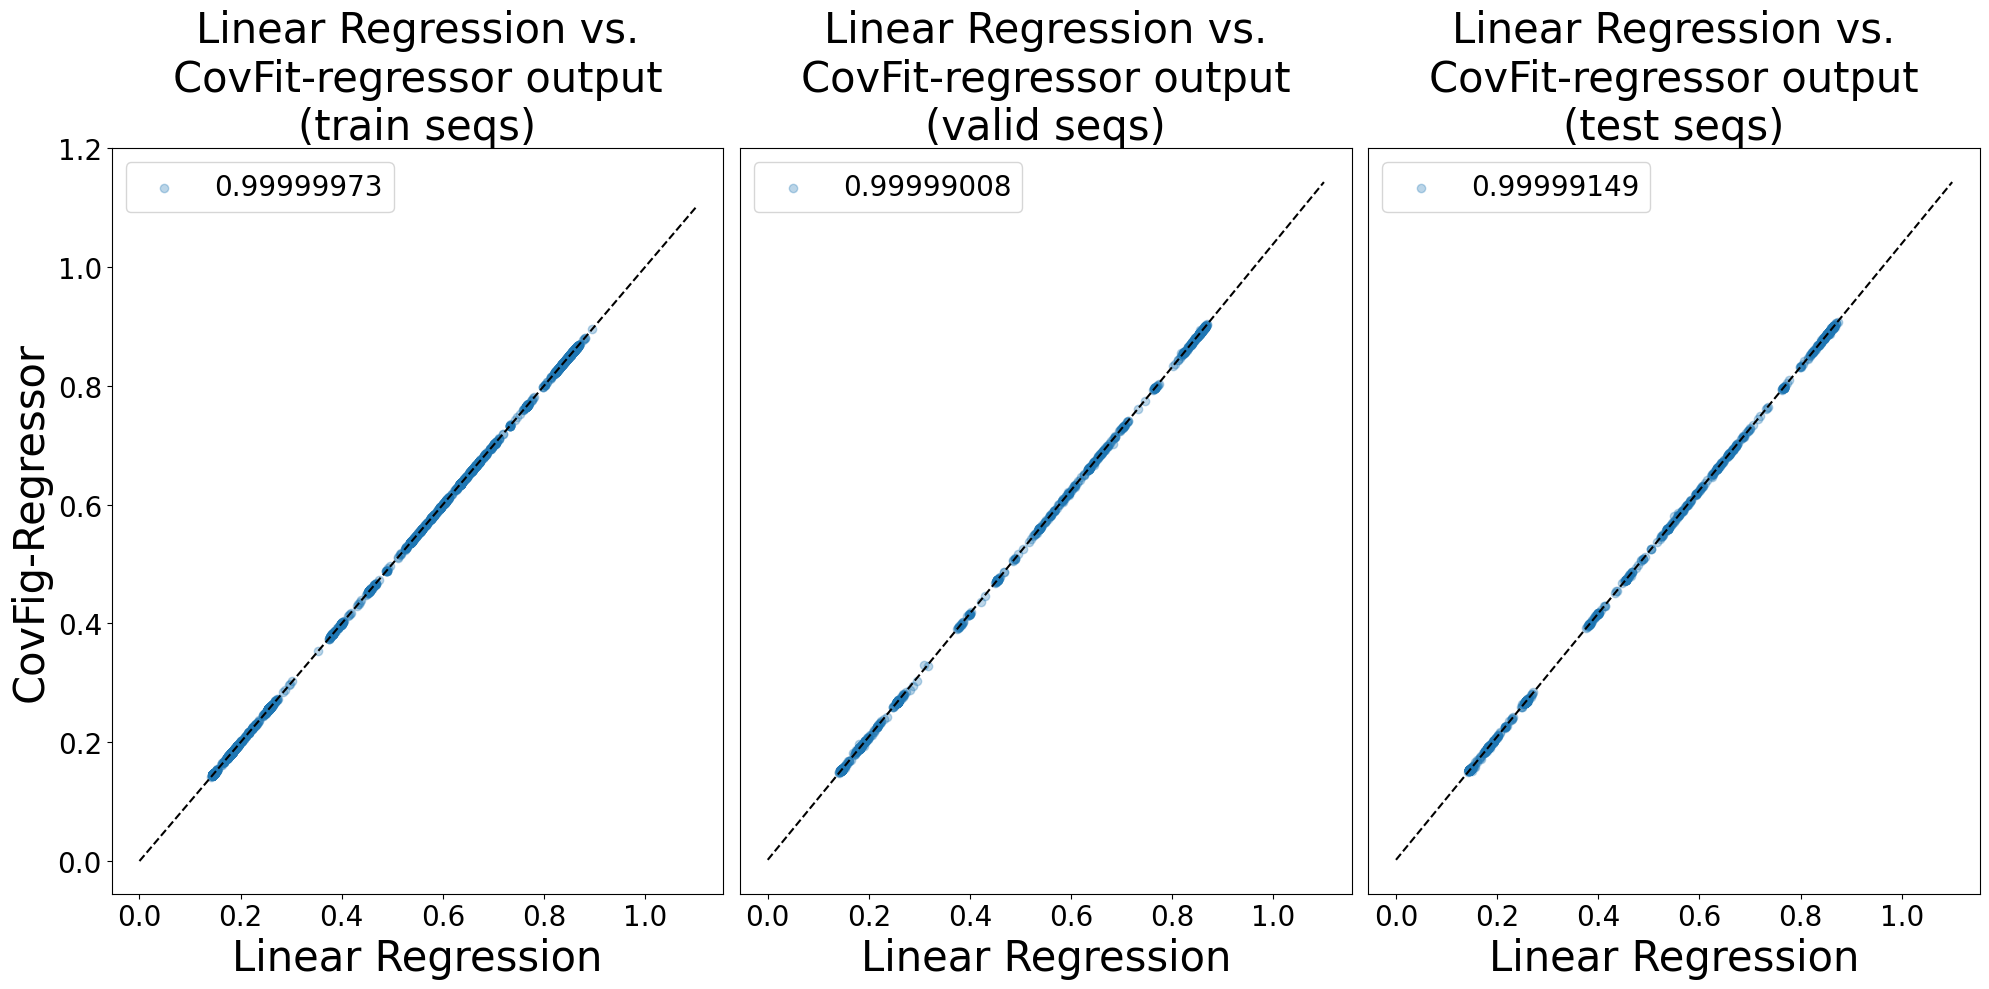

In [27]:
fit_linear_regression(
    hooked_esm_covfit,
    get_logit_hooked=get_logit_covfit,
    train_seqs=train_seqs,
    valid_seqs=valid_seqs,
    test_seqs=test_seqs,
    save_file="../figures/CovFit-regressor_linear_regression.png")

## CovFit L455F circuit eval
Let $\begin{cases} F(\cdot) \text{ denote model logit diff. when only including certain nodes (and mean-ablating others).} \\ C\text{ := circuit} \\ M \text{ := model}  \end{cases}$
* Completeness
    * $|F(M) - F(C)|$
* Faithfulness
    * $\forall K\subset C$, I plot $|F(M - K) - F(C - K)|$, where $-:=$ set-difference

In [ ]:
def get_diffs(
    model,
    seq_orig_toks,
    seq_new_toks,
    get_logit_hooked,
    n_batch=30,
    logit_id=logit_id
):
    assert seq_orig_toks.shape[0] == seq_new_toks.shape[0], "shape mismatch between seq_orig_toks and seq_new_toks!"

    diffs = np.zeros(seq_orig_toks.shape[0])

    for batch_idx in tqdm(range(0,seq_orig_toks.shape[0],n_batch)):
        batch_seq_orig = seq_orig_toks[batch_idx:batch_idx + n_batch]
        batch_seq_new = seq_new_toks[batch_idx:batch_idx + n_batch]

        batch_orig_output = get_logit_hooked(model(batch_seq_orig), logit_id)
        batch_new_output = get_logit_hooked(model(batch_seq_new), logit_id)

        diffs[batch_idx:batch_idx+n_batch] += (batch_new_output - batch_orig_output).cpu().numpy()
        del batch_orig_output
        del batch_new_output
        torch.cuda.empty_cache()

    return diffs

In [ ]:
def get_recovery_metrics(clean_out_pred, corr_out_pred, new_output, orig_output):
    clean_perf_recover = 1 - ((new_output - clean_out_pred).abs() / new_output).mean()
    corr_perf_recover = 1 - ((orig_output - corr_out_pred).abs() / orig_output).mean()

    fit_mean_diff_high_low = new_output.mean(dim=0).cpu().numpy() - orig_output.mean(dim=0).cpu().numpy()
    # fit_diff_recover = 1 - np.square((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.square(fit_mean_diff_high_low)
    fit_diff_recover = 1 - np.abs((clean_out_pred - corr_out_pred).mean().cpu().numpy() -  fit_mean_diff_high_low)/ np.abs(fit_mean_diff_high_low)
    new_diff = (clean_out_pred - corr_out_pred).mean().cpu().numpy()

    return clean_perf_recover, corr_perf_recover, fit_diff_recover, new_diff

In [ ]:
# HOOK FUNCTIONS for mean ablation
def abs_path_patch_head_input(
    orig_head_vector: Float[Tensor, "batch pos n_head d_head"],
    hook: HookPoint,
    new_comp: Float[Tensor, "pos n_head d_head"], # changed_head_vector at head_idx
    head_idx: Int[Tensor, "n_heads"]
):
    orig_head_vector[:,:,head_idx,:] = new_comp[:,head_idx,:]
    return orig_head_vector


def abs_path_patch_mlp_input(
    orig_mlp_vector: Float[Tensor, "batch pos d_model"],
    hook: HookPoint,
    new_comp: Float[Tensor, "pos d_model"], # changed_mlp_vector
):
    orig_mlp_vector[...] = new_comp[...]
    return orig_mlp_vector

# ACTUAL FUNCTION
def run_mean_ablate(
    model,
    toks: Int[Tensor, "batch seq_len"],
    ablation_cache,
    head_range: Bool[Tensor, "n_layer n_head"], # True if head should be mean-ablated otherwise False
    mlp_range: Bool[Tensor, "n_layer"], # True if mlp should be mean-ablated otherwise False
    verbose=False
):
    model.reset_hooks()
    for layer in range(model.cfg.n_layers):
        attn_name = f"blocks.{layer}.attn.hook_z"
        mlp_name = f"blocks.{layer}.hook_mlp_out"

        if torch.any(head_range[layer]):
            excl_heads = torch.argwhere(head_range[layer]).squeeze()
            model.add_hook(
                attn_name,
                functools.partial(abs_path_patch_head_input, new_comp=ablation_cache[attn_name].mean(dim=0), head_idx=excl_heads),
                dir="fwd"
            )
            if verbose:
                print(f"excluding heads: {layer}-{excl_heads}")

        if mlp_range[layer]:
            model.add_hook(
                mlp_name,
                functools.partial(abs_path_patch_mlp_input, new_comp=ablation_cache[mlp_name].mean(dim=0)),
                dir="fwd"
            )
            if verbose:
                print(f"excluding mlp: {layer}\n")

    ablated_output = model(toks) # [batch pos d_model]
    ablated_logits = get_logit_hooked(ablated_output, logit_id)
    torch.cuda.empty_cache()
    model.reset_hooks()

    return ablated_logits


#### Circuit
* Attn. heads: L0.all, L1.H15, L2.[4,17], L12.18, L13.[5,9], L14.6, L32.[5,8,13], L31.[1,2,3,7,8,9,12,13,14,15,17]
* MLP blocks: [0,2,8,11,14,15,16,18-25,26-31]

In [ ]:
head_range = torch.full((hooked_esm.cfg.n_layers, hooked_esm.cfg.n_heads), fill_value=True)
head_range[0,:] = False

head_range[1,15] = False
head_range[2,[4,17]] = False
head_range[12,18] = False
head_range[13,[5,9]] = False
head_range[14,6] = False

head_range[32][[5,8,13]] = False
head_range[31][[1,2,3,7,8,9,12,13,14,15,17]] = False

mlp_range = torch.full((hooked_esm.cfg.n_layers, 1), fill_value=True).squeeze()
mlp_range[[0,2,8,11,14,15,16,*list(range(18,26,1)),*list(range(26,32,1))]] = False
# mlp_range[[0,2,8,11,14,15,16,*list(range(18,26,1)),*list(range(26,33,1))]] = False
# mlp_range[[0,11,24,26,27,28,29,30,31]] = False

In [ ]:
def run_mean_ablate_batched(
    model,
    batch_dim,
    orig_toks, # L455 seqs
    new_toks, # F455 seqs
    ablate_toks, # ablation dset seqs (<mask>455)
    head_range: Bool[Tensor, "n_layer n_head"], # True if head should be mean-ablated otherwise False
    mlp_range: Bool[Tensor, "n_layer"], # True if mlp should be mean-ablated otherwise False
    verbose = lambda i: True if i == 0 else False
):
    attn_names = [utils.get_act_name("z", layer) for layer in range(hooked_esm.cfg.n_layers)]
    mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

    l_ablate_logits = torch.empty(clean_toks.shape[0]).to(device)
    f_ablate_logits = torch.empty(clean_toks.shape[0]).to(device)

    for i in range(0,clean_toks.shape[0],batch_dim):
        batch_L = orig_toks[i:(i+batch_dim)]
        batch_F = new_toks[i:(i+batch_dim)]
        batch_ablate = ablate_toks[i:(i+batch_dim)]

        _, ablate_cache = hooked_esm.run_with_cache(batch_ablate, names_filter=[*attn_names, *mlp_names])

        l_ablate_logits[i:(i+batch_dim)] = run_mean_ablate(hooked_esm, batch_L, ablate_cache, head_range=head_range, mlp_range=mlp_range, verbose=verbose(i))
        torch.cuda.empty_cache()
        f_ablate_logits[i:(i+batch_dim)] = run_mean_ablate(hooked_esm, batch_F, ablate_cache, head_range=head_range, mlp_range=mlp_range)
        torch.cuda.empty_cache()

        del _
        del ablate_cache
        torch.cuda.empty_cache()

    return l_ablate_logits, f_ablate_logits

In [ ]:
l_ablate_logits, f_ablate_logits = run_mean_ablate_batched(
    hooked_esm,
    batch_dim=80,
    orig_toks=orig_toks,
    new_toks=new_toks,
    ablate_toks=ablate_toks,
    head_range=head_range,
    mlp_range=mlp_range
)

In [ ]:
clean_perf_recover, corr_perf_recover, fit_diff_recover, new_diff = get_recovery_metrics(f_ablate_logits, l_ablate_logits, new_output=new_output, orig_output=orig_output)
clean_perf_recover = clean_perf_recover.cpu().numpy()
corr_perf_recover = corr_perf_recover.cpu().numpy()

In [ ]:
fit_mean_diff_high_low = get_diffs(
    hooked_esm_covfit,
    seq_orig_toks=corr_toks,
    seq_new_toks=clean_toks,
    get_logit_hooked=get_logit_covfit,
).mean()